In [1]:
import sys
from pathlib import Path

# Add the parent directory to the system path
sys.path.append(str(Path.cwd().parent.resolve()))

In [2]:
# Load Libraries
import numpy as np
import pandas as pd
from pyod import models
import plotly.express as px
from sklearn import metrics
from datetime import datetime
import matplotlib.dates as md
from matplotlib import pyplot as plt
from prettytable import PrettyTable
from pyod.models.pca import PCA
from pyod.models.ocsvm import OCSVM
from pyod.models.knn import KNN
from pyod.models.lof import LOF

In [3]:
# Data Path
path = str(Path.cwd().parent.resolve())
dma_path = path + "/data/DMA_X.csv"

In [4]:
# Load Data
dma_flow = pd.read_csv(dma_path, index_col='TimeStamp', date_format='%d/%m/%Y %H:%M')
dma_flow['Flow'] = dma_flow['Flow'].ewm(alpha=0.75, adjust=False).mean()

# Curate Flows between 00:00 - 6:00 and Visualize
group_dma_flow = dma_flow.between_time('00:00:00', '05:59:00')
px.line(group_dma_flow, x=group_dma_flow.index, y=['Flow'])

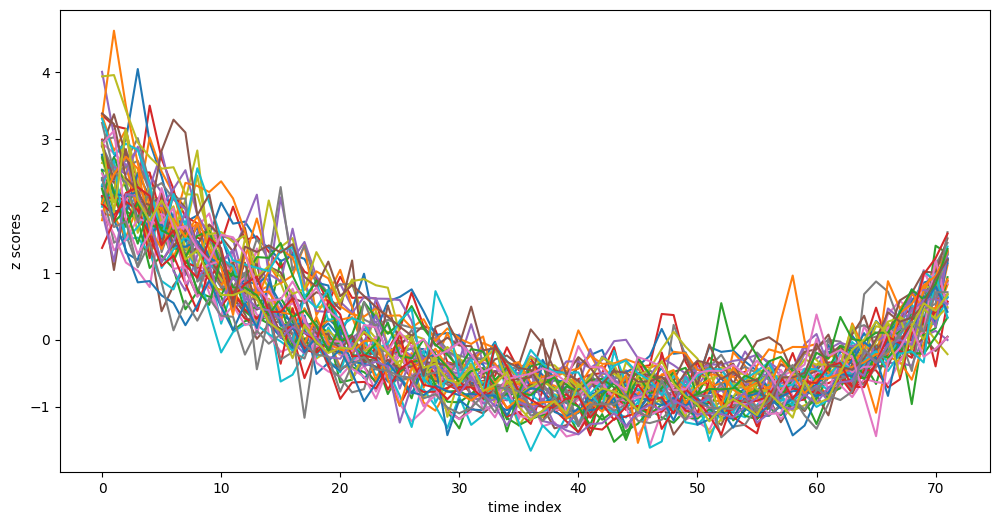

In [5]:
# Mean and Standard Deviation of Group Data
non_leak_data = group_dma_flow.loc['2022-04-02 00:00:00':'2022-05-20 23:59:00']
mean = non_leak_data.mean()
std = non_leak_data.std()

# Feature Engineering of Group Data
standardized_non_leak_data = (non_leak_data - mean) / std

def create_sequences(values, time_steps):
    output = []
    for i in range(0,len(values),time_steps):
        seq = values[i : (i + time_steps)]
        output.append(seq)
    return np.stack(output)

train_data = create_sequences(standardized_non_leak_data['Flow'].values, 72)

# Visualise Benign Group Representation
fig, ax = plt.subplots(figsize=(12,6))
for i in np.arange(0,len(train_data)):
  ax.plot(train_data[i,:])
ax.set_ylabel('z scores')
ax.set_xlabel('time index')
plt.show()

In [6]:
# Instantiate AD Models
pca_model = PCA(contamination=1e-6)
ocsvm_model = OCSVM(contamination=1e-6)
knn_model = KNN(contamination=1e-6)
lof_model = LOF(contamination=1e-6)

# Fit Models
pca_model.fit(train_data)
ocsvm_model.fit(train_data)
knn_model.fit(train_data)
lof_model.fit(train_data)

# Transform Test Data
standardized_group_dma_flow = (group_dma_flow - mean) / std
test_data = create_sequences(standardized_group_dma_flow['Flow'].values, 72)

# Test Models
pca_test_pred = pca_model.predict(test_data)
ocsvm_test_pred = ocsvm_model.predict(test_data)
knn_test_pred = knn_model.predict(test_data)
lof_test_pred = lof_model.predict(test_data)

# Identify Leak Indexes
daily_dma_flow = dma_flow.resample('1D').median()
pca_leak_events = daily_dma_flow.loc[list(map(bool,pca_test_pred))]
ocsvm_leak_events = daily_dma_flow.loc[list(map(bool,ocsvm_test_pred))]
knn_leak_events = daily_dma_flow.loc[list(map(bool,knn_test_pred))]
lof_leak_events = daily_dma_flow.loc[list(map(bool,lof_test_pred))]

# Ground Truth on Leakages
leak_starttime = '2022-06-01 00:00:00'
leak_endtime = '2022-06-14 23:55:00'

[]

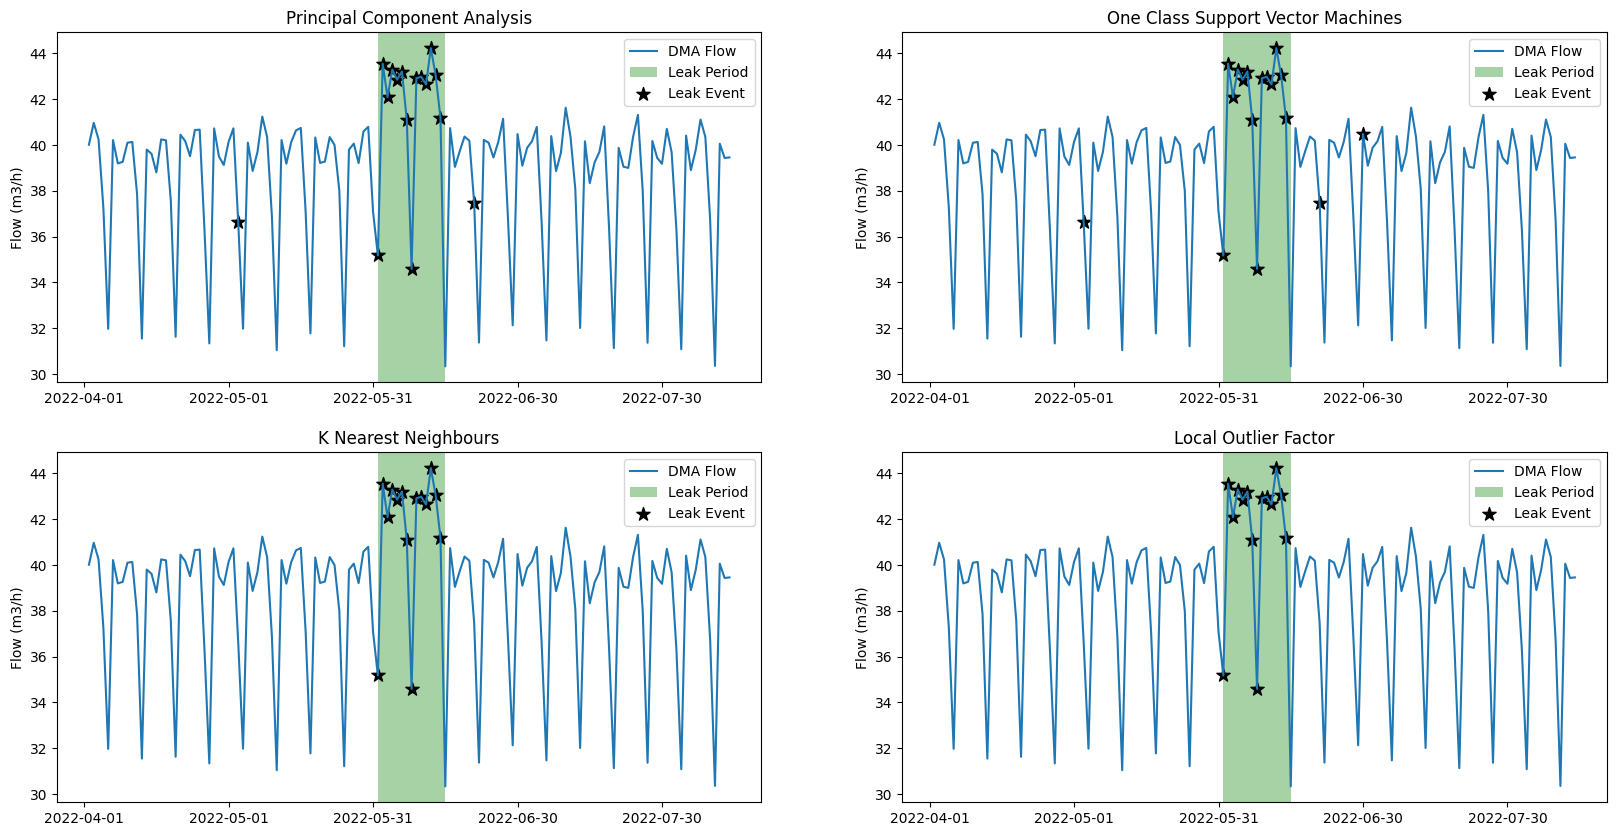

In [7]:
# Visualize Leaks
fig, ax = plt.subplots(2,2, figsize=(20, 10))
date_locator = md.DayLocator(interval=30)

ax[0,0].plot(daily_dma_flow.index.values, daily_dma_flow.values, label='DMA Flow')
ax[0,0].axvspan(leak_starttime, leak_endtime, facecolor='green', alpha=0.35, label='Leak Period')
ax[0,0].scatter(pca_leak_events.index, pca_leak_events['Flow'], 100, marker='*', c='k',label='Leak Event')
ax[0,0].set_title('Principal Component Analysis')
ax[0,0].xaxis.set_major_locator(date_locator)
ax[0,0].set_ylabel('Flow (m3/h)')
ax[0,0].legend(loc=1)

ax[0,1].plot(daily_dma_flow.index.values, daily_dma_flow.values, label='DMA Flow')
ax[0,1].axvspan(leak_starttime, leak_endtime, facecolor='green', alpha=0.35, label='Leak Period')
ax[0,1].scatter(ocsvm_leak_events.index, ocsvm_leak_events['Flow'], 100, marker='*', c='k',label='Leak Event')
ax[0,1].set_title('One Class Support Vector Machines')
ax[0,1].xaxis.set_major_locator(date_locator)
ax[0,1].set_ylabel('Flow (m3/h)')
ax[0,1].legend(loc=1)

ax[1,0].plot(daily_dma_flow.index.values, daily_dma_flow.values, label='DMA Flow')
ax[1,0].axvspan(leak_starttime, leak_endtime, facecolor='green', alpha=0.35, label='Leak Period')
ax[1,0].scatter(knn_leak_events.index, knn_leak_events['Flow'], 100, marker='*', c='k',label='Leak Event')
ax[1,0].set_title('K Nearest Neighbours')
ax[1,0].xaxis.set_major_locator(date_locator)
ax[1,0].set_ylabel('Flow (m3/h)')
ax[1,0].legend(loc=1)

ax[1,1].plot(daily_dma_flow.index.values, daily_dma_flow.values, label='DMA Flow')
ax[1,1].axvspan(leak_starttime, leak_endtime, facecolor='green', alpha=0.35, label='Leak Period')
ax[1,1].scatter(lof_leak_events.index, lof_leak_events['Flow'], 100, marker='*', c='k',label='Leak Event')
ax[1,1].set_title('Local Outlier Factor')
ax[1,1].xaxis.set_major_locator(date_locator)
ax[1,1].set_ylabel('Flow (m3/h)')
ax[1,1].legend(loc=1)

plt.plot()

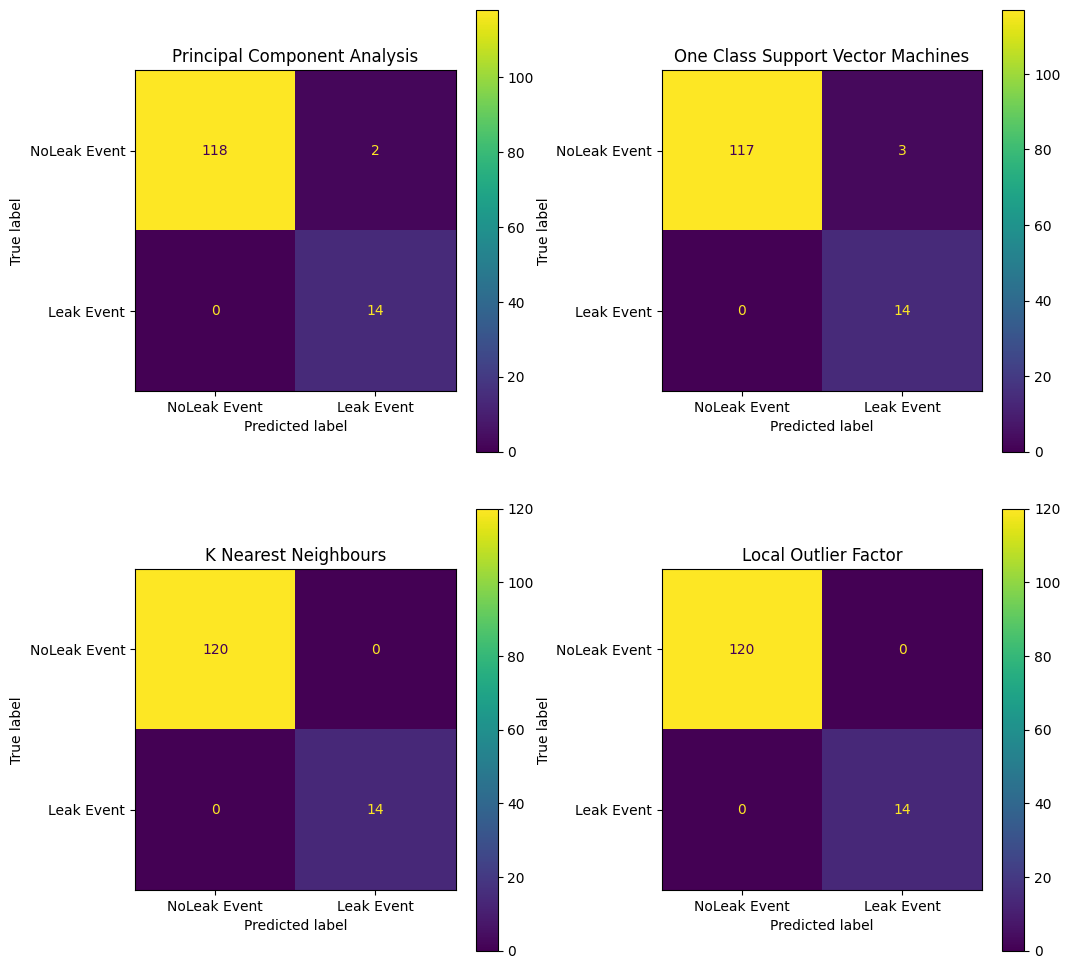

In [8]:
# Leak Ground Turth labels
leak_results = pd.DataFrame()
leak_results.index = daily_dma_flow.index
leak_results['Truth'] = np.zeros((len(daily_dma_flow)), dtype=int)
leak_results.loc[leak_starttime:leak_endtime,'Truth'] = int(1)
class_labels = ['NoLeak Event','Leak Event']

# PCA Predicted Labels
leak_results['PCA Predicted'] = np.zeros((len(daily_dma_flow)), dtype=int)
leak_results.loc[pca_leak_events.index,'PCA Predicted'] = int(1)
pca_cm = metrics.confusion_matrix(leak_results['Truth'].values, leak_results['PCA Predicted'].values)
pca_cm_plot = metrics.ConfusionMatrixDisplay(confusion_matrix=pca_cm, display_labels=class_labels)

# OCSVM Predicted Labels
leak_results['OCSVM Predicted'] = np.zeros((len(daily_dma_flow)), dtype=int)
leak_results.loc[ocsvm_leak_events.index,'OCSVM Predicted'] = int(1)
ocsvm_cm = metrics.confusion_matrix(leak_results['Truth'].values, leak_results['OCSVM Predicted'].values)
ocsvm_cm_plot = metrics.ConfusionMatrixDisplay(confusion_matrix=ocsvm_cm, display_labels=class_labels)

# KNN Predicted Labels
leak_results['KNN Predicted'] = np.zeros((len(daily_dma_flow)), dtype=int)
leak_results.loc[knn_leak_events.index,'KNN Predicted'] = int(1)
knn_cm = metrics.confusion_matrix(leak_results['Truth'].values, leak_results['KNN Predicted'].values)
knn_cm_plot = metrics.ConfusionMatrixDisplay(confusion_matrix=knn_cm, display_labels=class_labels)

# LOF Predicted Labels
leak_results['LOF Predicted'] = np.zeros((len(daily_dma_flow)), dtype=int)
leak_results.loc[lof_leak_events.index,'LOF Predicted'] = int(1)
lof_cm = metrics.confusion_matrix(leak_results['Truth'].values, leak_results['LOF Predicted'].values)
lof_cm_plot = metrics.ConfusionMatrixDisplay(confusion_matrix=lof_cm, display_labels=class_labels)


# Visualize Confusion Matrix
fig, ax = plt.subplots(2,2, figsize=(10, 10))
fig.tight_layout(h_pad=2.0, w_pad=6.0)

pca_cm_plot.plot(ax=ax[0,0])
ocsvm_cm_plot.plot(ax=ax[0,1])
knn_cm_plot.plot(ax=ax[1,0])
lof_cm_plot.plot(ax=ax[1,1])

ax[0,0].set_title('Principal Component Analysis')
ax[0,1].set_title('One Class Support Vector Machines')
ax[1,0].set_title('K Nearest Neighbours')
ax[1,1].set_title('Local Outlier Factor')

plt.show()

In [9]:
# PCA Performance Scores
pca_recall = metrics.recall_score(leak_results['Truth'].values, leak_results['PCA Predicted'].values)
pca_precision = metrics.precision_score(leak_results['Truth'].values, leak_results['PCA Predicted'].values)
pca_fbeta_score = metrics.fbeta_score(leak_results['Truth'].values, leak_results['PCA Predicted'].values, beta=1/3)

# OCSVM Performance Scores
ocsvm_recall = metrics.recall_score(leak_results['Truth'].values, leak_results['OCSVM Predicted'].values)
ocsvm_precision = metrics.precision_score(leak_results['Truth'].values, leak_results['OCSVM Predicted'].values)
ocsvm_fbeta_score = metrics.fbeta_score(leak_results['Truth'].values, leak_results['OCSVM Predicted'].values, beta=1/3)

# KNN Performance Scores
knn_recall = metrics.recall_score(leak_results['Truth'].values, leak_results['KNN Predicted'].values)
knn_precision = metrics.precision_score(leak_results['Truth'].values, leak_results['KNN Predicted'].values)
knn_fbeta_score = metrics.fbeta_score(leak_results['Truth'].values, leak_results['KNN Predicted'].values, beta=1/3)

# LOF Performance Scores
lof_recall = metrics.recall_score(leak_results['Truth'].values, leak_results['LOF Predicted'].values)
lof_precision = metrics.precision_score(leak_results['Truth'].values, leak_results['LOF Predicted'].values)
lof_fbeta_score = metrics.fbeta_score(leak_results['Truth'].values, leak_results['LOF Predicted'].values, beta=1/3)

# Set of Identified Leak Days
true_leakset = set(leak_results.loc[leak_starttime:leak_endtime].index.values.tolist())
pca_leakset = set(leak_results.loc[pca_leak_events.index].index.values.tolist())
ocsvm_leakset = set(leak_results.loc[ocsvm_leak_events.index].index.values.tolist())
knn_leakset = set(leak_results.loc[knn_leak_events.index].index.values.tolist())
lof_leakset = set(leak_results.loc[lof_leak_events.index].index.values.tolist())

# Earliest Leak Identification Time (IT)
true_it = min(true_leakset)
pca_it = min(true_leakset & pca_leakset)
ocsvm_it = min(true_leakset & ocsvm_leakset)
knn_it = min(true_leakset & knn_leakset)
lof_it = min(true_leakset & lof_leakset)

# Identification Lag Time
pca_lagtime = (pca_it - true_it).days
ocsvm_lagtime = (ocsvm_it - true_it).days
knn_lagtime = (knn_it - true_it).days
lof_lagtime = (lof_it - true_it).days

# Print Table of Scores
table_entries = [['Recall', np.round(pca_recall,2), np.round(ocsvm_recall,2), np.round(knn_recall,2), np.round(lof_recall,2)], \
                 ['Precision', np.round(pca_precision,2), np.round(ocsvm_precision,2), np.round(knn_precision,2), np.round(lof_precision,2)], \
                 ['FScore(1/3)', np.round(pca_fbeta_score,2), np.round(ocsvm_fbeta_score,2), np.round(knn_fbeta_score,2), np.round(lof_fbeta_score,2)],\
                 ['Lag Time', str(pca_lagtime)+' days', str(ocsvm_lagtime)+' days', str(knn_lagtime)+' days', str(lof_lagtime)+' days']]
scores_table = PrettyTable(['','PCA', 'OCSVM', 'KNN', 'LOF'])
scores_table.add_rows(table_entries)
print(scores_table)

+-------------+--------+--------+--------+--------+
|             |  PCA   | OCSVM  |  KNN   |  LOF   |
+-------------+--------+--------+--------+--------+
|    Recall   |  1.0   |  1.0   |  1.0   |  1.0   |
|  Precision  |  0.88  |  0.82  |  1.0   |  1.0   |
| FScore(1/3) |  0.89  |  0.84  |  1.0   |  1.0   |
|   Lag Time  | 0 days | 0 days | 0 days | 0 days |
+-------------+--------+--------+--------+--------+
